Global E-Commerce Forecasting
Beth Du
**Dataset name:** global_ecommerce_forecasting.csv  
**Source URL:** https://www.kaggle.com/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

file_path = "global_ecommerce_forecasting.csv"
df = pd.read_csv(file_path)

print("Original shape:", df.shape)
display(df.head())
display(df.dtypes)

Original shape: (100000, 18)


,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,21523,13085,5.95,10,59.50,62276270.0,2.412840e+12,-17.633976,1.89709
1,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,79323W,13085,6.75,12,81.00,62276270.0,2.412840e+12,-17.633976,1.89709
2,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,82582,13078,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.89709
3,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,22111,13078,4.25,24,102.00,62276270.0,2.412840e+12,-17.633976,1.89709
4,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,21756,13078,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.89709


order_datetime             object
year                        int64
month                       int64
week_of_year                int64
day_of_week                 int64
order_hour                  int64
is_weekend                  int64
country                    object
country_code               object
product_id                 object
customer_id                 int64
unit_price_gbp            float64
quantity_sold               int64
sales_amount_gbp          float64
population_total          float64
gdp_current_usd           float64
gdp_growth_pct            float64
inflation_consumer_pct    float64
dtype: object

Preprocessing
1. Handle missing values
2. Remove duplicates
3. Handle invalid values for expected type/range
4. Handle outliers
5. Normalize dates to a standard format (`YYYY-MM-DD`)

For each function, I first check whether the issue exists in the dataset.
If it does not, I demonstrate the function on a small made-up example.

In [23]:
# Make a working copy
clean_df = df.copy()

# Parse datetime once for later use
clean_df["order_datetime"] = pd.to_datetime(clean_df["order_datetime"], errors="coerce")

print("Working copy shape:", clean_df.shape)
print("Datetime parse failures:", clean_df["order_datetime"].isna().sum())

Working copy shape: (100000, 18)
Datetime parse failures: 0


1. Handle Missing Values

In [24]:
def handle_missing_values(dataframe):
    df_copy = dataframe.copy()
    missing_rows = df_copy[df_copy.isna().any(axis=1)].copy()
    
    if missing_rows.empty:
        print("No missing values found in the actual dataset.")
        
        demo_df = pd.DataFrame({
            "country": ["United Kingdom", None, "France", "Germany", None],
            "unit_price_gbp": [10.5, 15.0, np.nan, 8.0, 12.0],
            "quantity_sold": [1, 2, 3, np.nan, 5]
        })
        
        print("\nMade-up example before cleaning:")
        display(demo_df)
        
        demo_clean = demo_df.copy()
        for col in demo_clean.columns:
            if pd.api.types.is_numeric_dtype(demo_clean[col]):
                demo_clean[col] = demo_clean[col].fillna(demo_clean[col].median())
            else:
                demo_clean[col] = demo_clean[col].fillna(demo_clean[col].mode()[0])
        
        print("Made-up example after cleaning:")
        display(demo_clean)
        return df_copy
    else:
        print("Missing values found in actual dataset.")
        print("Rows with missing values before cleaning:")
        display(missing_rows)
        
        for col in df_copy.columns:
            if df_copy[col].isna().sum() > 0:
                if pd.api.types.is_numeric_dtype(df_copy[col]):
                    df_copy[col] = df_copy[col].fillna(df_copy[col].median())
                else:
                    df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])
        
        changed_rows = df_copy.loc[missing_rows.index]
        print("rows after cleaning:")
        display(changed_rows)
        return df_copy

clean_df = handle_missing_values(clean_df)

No missing values found in the actual dataset.

Made-up example before cleaning:


,country,unit_price_gbp,quantity_sold
0,United Kingdom,10.5,1.0
1,None,15.0,2.0
2,France,NaN,3.0
3,Germany,8.0,NaN
4,None,12.0,5.0


Made-up example after cleaning:


,country,unit_price_gbp,quantity_sold
0,United Kingdom,10.50,1.0
1,France,15.00,2.0
2,France,11.25,3.0
3,Germany,8.00,2.5
4,France,12.00,5.0


2. Remove Duplicates

In [25]:
def remove_duplicates(dataframe):
    df_copy = dataframe.copy()
    duplicate_mask = df_copy.duplicated()
    duplicate_rows = df_copy[duplicate_mask].copy()
    
    print("Number of duplicate rows found:", duplicate_mask.sum())
    
    if duplicate_rows.empty:
        print("No duplicates found.")
        return df_copy
    else:
        print("\nDuplicate rows to be removed (with row numbers):")
        display(duplicate_rows)
        
        df_copy = df_copy.drop_duplicates().reset_index(drop=True)
        
        print("Shape after removing duplicates:", df_copy.shape)
        return df_copy

clean_df = remove_duplicates(clean_df)

Number of duplicate rows found: 255

Duplicate rows to be removed (with row numbers):


,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
1792,2009-12-04 14:19:00,2009,12,49,4,14,0,United Kingdom,GBR,21490,12970,1.95,2,3.90,62276270.0,2.412840e+12,-17.633976,1.897090
2051,2009-12-06 11:13:00,2009,12,49,6,11,1,United Kingdom,GBR,22196,17920,0.85,1,0.85,62276270.0,2.412840e+12,-17.633976,1.897090
2132,2009-12-06 12:14:00,2009,12,49,6,12,1,United Kingdom,GBR,21232,13448,1.25,6,7.50,62276270.0,2.412840e+12,-17.633976,1.897090
3416,2009-12-09 13:49:00,2009,12,50,2,13,0,Germany,DEU,21843,12709,9.95,24,238.80,81902307.0,3.411261e+12,-8.918006,1.994704
3421,2009-12-09 13:49:00,2009,12,50,2,13,0,Germany,DEU,21916,12709,0.42,24,10.08,81902307.0,3.411261e+12,-8.918006,1.994704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97381,2010-12-02 19:59:00,2010,12,48,3,19,0,United Kingdom,GBR,20983,14573,0.85,1,0.85,62766365.0,2.485483e+12,3.010668,1.589081
97795,2010-12-05 11:12:00,2010,12,48,6,11,1,United Kingdom,GBR,85175,15708,0.42,32,13.44,62766365.0,2.485483e+12,3.010668,1.589081
98286,2010-12-05 15:15:00,2010,12,48,6,15,1,United Kingdom,GBR,22633,15953,2.10,1,2.10,62766365.0,2.485483e+12,3.010668,1.589081
98486,2010-12-06 11:26:00,2010,12,49,0,11,0,United Kingdom,GBR,21163,15919,1.45,1,1.45,62766365.0,2.485483e+12,3.010668,1.589081


Shape after removing duplicates: (99745, 18)


3. Handle Invalid Values for Expected Type and Range

In [26]:
def handle_invalid_values(dataframe):
    df_copy = dataframe.copy()
    
    invalid_mask = (
        (df_copy["month"] < 1) | (df_copy["month"] > 12) |
        (df_copy["day_of_week"] < 0) | (df_copy["day_of_week"] > 6) |
        (df_copy["order_hour"] < 0) | (df_copy["order_hour"] > 23) |
        (~df_copy["is_weekend"].isin([0, 1])) |
        (df_copy["unit_price_gbp"] <= 0) |
        (df_copy["quantity_sold"] <= 0) |
        (df_copy["sales_amount_gbp"] < 0)
    )
    
    invalid_rows = df_copy[invalid_mask].copy()
    
    if invalid_rows.empty:
        print("No invalid type/range values found in the actual dataset.")
        
        demo_df = pd.DataFrame({
            "month": [1, 13, 5, 0, 12],
            "day_of_week": [0, 7, 3, -1, 2],
            "order_hour": [10, 25, -3, 18, 7],
            "is_weekend": [0, 1, 2, 0, 5],
            "unit_price_gbp": [10.0, -2.5, 15.0, 0.0, 8.0],
            "quantity_sold": [1, 2, 0, -4, 3],
            "sales_amount_gbp": [10.0, -5.0, 30.0, 20.0, 24.0]
        })
        
        print("\nMade-up example before cleaning:")
        display(demo_df)
        
        demo_clean = demo_df.copy()
        demo_clean["month"] = demo_clean["month"].clip(1, 12)
        demo_clean["day_of_week"] = demo_clean["day_of_week"].clip(0, 6)
        demo_clean["order_hour"] = demo_clean["order_hour"].clip(0, 23)
        demo_clean["is_weekend"] = demo_clean["is_weekend"].apply(lambda x: 1 if x == 1 else 0)
        demo_clean["unit_price_gbp"] = demo_clean["unit_price_gbp"].apply(lambda x: x if x > 0 else np.nan)
        demo_clean["quantity_sold"] = demo_clean["quantity_sold"].apply(lambda x: x if x > 0 else np.nan)
        demo_clean["sales_amount_gbp"] = demo_clean["sales_amount_gbp"].apply(lambda x: x if x >= 0 else np.nan)
        
        for col in demo_clean.columns:
            if demo_clean[col].isna().sum() > 0:
                demo_clean[col] = demo_clean[col].fillna(demo_clean[col].median())
        
        print("Made-up example after cleaning:")
        display(demo_clean)
        return df_copy
    
    else:
        print("Invalid rows befre cleaning:")
        display(invalid_rows)
        
        df_copy["month"] = df_copy["month"].clip(1, 12)
        df_copy["day_of_week"] = df_copy["day_of_week"].clip(0, 6)
        df_copy["order_hour"] = df_copy["order_hour"].clip(0, 23)
        df_copy["is_weekend"] = df_copy["is_weekend"].apply(lambda x: 1 if x == 1 else 0)
        df_copy["unit_price_gbp"] = df_copy["unit_price_gbp"].apply(lambda x: x if x > 0 else np.nan)
        df_copy["quantity_sold"] = df_copy["quantity_sold"].apply(lambda x: x if x > 0 else np.nan)
        df_copy["sales_amount_gbp"] = df_copy["sales_amount_gbp"].apply(lambda x: x if x >= 0 else np.nan)
        
        for col in ["unit_price_gbp", "quantity_sold", "sales_amount_gbp"]:
            df_copy[col] = df_copy[col].fillna(df_copy[col].median())
        
        print("Rows AFTER cleaning:")
        display(df_copy.loc[invalid_rows.index])
        return df_copy

clean_df = handle_invalid_values(clean_df)

No invalid type/range values found in the actual dataset.

Made-up example before cleaning:


,month,day_of_week,order_hour,is_weekend,unit_price_gbp,quantity_sold,sales_amount_gbp
0,1,0,10,0,10.0,1,10.0
1,13,7,25,1,-2.5,2,-5.0
2,5,3,-3,2,15.0,0,30.0
3,0,-1,18,0,0.0,-4,20.0
4,12,2,7,5,8.0,3,24.0


Made-up example after cleaning:


,month,day_of_week,order_hour,is_weekend,unit_price_gbp,quantity_sold,sales_amount_gbp
0,1,0,10,0,10.0,1.0,10.0
1,12,6,23,1,10.0,2.0,22.0
2,5,3,0,0,15.0,2.0,30.0
3,1,0,18,0,10.0,2.0,20.0
4,12,2,7,0,8.0,3.0,24.0


4. Handle Outliers

In [27]:
def handle_outliers(dataframe, columns):
    df_copy = dataframe.copy()
    changed_index = set()
    
    for col in columns:
        q1 = df_copy[col].quantile(0.25)
        q3 = df_copy[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outlier_mask = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)
        changed_index.update(df_copy[outlier_mask].index.tolist())
        
        df_copy[col] = df_copy[col].clip(lower=lower_bound, upper=upper_bound)
    
    changed_index = sorted(changed_index)
    
    print("Number of rows affected by outlier capping:", len(changed_index))
    
    if len(changed_index) == 0:
        print("No outliers found.")
        return df_copy
    else:
        print("\nRows after outlier handling:")
        display(df_copy.loc[changed_index, ["unit_price_gbp", "quantity_sold", "sales_amount_gbp"]].head(10))
        
        print("\nSmall sample of affected columns after applying the function:")
        display(df_copy.loc[changed_index, ["unit_price_gbp", "quantity_sold", "sales_amount_gbp"]].sample(min(5, len(changed_index)), random_state=42))
        return df_copy

clean_df = handle_outliers(
    clean_df,
    columns=["unit_price_gbp", "quantity_sold", "sales_amount_gbp"]
)

Number of rows affected by outlier capping: 20082

Rows after outlier handling:


,unit_price_gbp,quantity_sold,sales_amount_gbp
0,5.95,10,41.10
1,6.75,12,41.10
3,4.25,24,41.10
5,0.98,27,27.44
13,7.50,3,41.10
14,7.50,2,15.90
19,4.95,9,41.10
20,4.95,9,41.10
32,3.39,24,41.10
33,7.50,1,41.10



Small sample of affected columns after applying the function:


,unit_price_gbp,quantity_sold,sales_amount_gbp
64638,7.50,2,17.90
26460,7.50,1,9.95
83068,2.55,27,41.10
30693,7.50,2,25.50
79838,1.95,24,41.10


5. Normalize Dates to a Standard Format (`YYYY-MM-DD`)

In [28]:
def normalize_dates(dataframe, date_column):
    df_copy = dataframe.copy()
    
    parsed_dates = pd.to_datetime(df_copy[date_column], errors="coerce")
    bad_dates = df_copy[parsed_dates.isna()].copy()
    
    if bad_dates.empty:
        print("All dates in the actual dataset are already parseable.")
        
        demo_df = pd.DataFrame({
            "raw_date": ["2024/01/05", "01-06-2024", "2024.01.07", "Jan 8 2024", "2024-01-09"]
        })
        
        print("\nMade-up example before normalization:")
        display(demo_df)
        
        demo_df["normalized_date"] = pd.to_datetime(demo_df["raw_date"], errors="coerce").dt.strftime("%Y-%m-%d")
        
        print("Made-up example after normalization:")
        display(demo_df)
    else:
        print("Unparseable dates found:")
        display(bad_dates)
    
    df_copy["order_date"] = parsed_dates.dt.strftime("%Y-%m-%d")
    
    print("\nSmall sample of normalized dates:")
    display(df_copy[[date_column, "order_date"]].head(10))
    
    return df_copy

clean_df = normalize_dates(clean_df, "order_datetime")

All dates in the actual dataset are already parseable.

Made-up example before normalization:


,raw_date
0,2024/01/05
1,01-06-2024
2,2024.01.07
3,Jan 8 2024
4,2024-01-09


Made-up example after normalization:


,raw_date,normalized_date
0,2024/01/05,2024-01-05
1,01-06-2024,NaN
2,2024.01.07,NaN
3,Jan 8 2024,NaN
4,2024-01-09,NaN



Small sample of normalized dates:


,order_datetime,order_date
0,2009-12-01 07:45:00,2009-12-01
1,2009-12-01 07:45:00,2009-12-01
2,2009-12-01 09:06:00,2009-12-01
3,2009-12-01 09:06:00,2009-12-01
4,2009-12-01 09:06:00,2009-12-01
5,2009-12-01 09:24:00,2009-12-01
6,2009-12-01 09:28:00,2009-12-01
7,2009-12-01 09:28:00,2009-12-01
8,2009-12-01 09:28:00,2009-12-01
9,2009-12-01 09:28:00,2009-12-01


Summary

Issues present in the actual dataset
Duplicate rows were present, so I removed them.
Outliers were present in numeric columns such as `unit_price_gbp`, `quantity_sold`, and `sales_amount_gbp`, so I capped them using the IQR method.
Dates were parseable, and I normalized them into a standard `YYYY-MM-DD` column called `order_date`.

Issues not present in the actual dataset:
Missing values were not present, so I demonstrated the missing-value function on a small made-up example.
Invalid type/range values were not present in the actual dataset, so I demonstrated that function on a small made-up example with impossible values such as month 13, negative prices, and invalid weekend flags.

Analysis
This section implements 4 distinct tasks from the assignment list using different column combinations.

Top-N Within Each Group
For each country, show the top 3 products ranked by total sales amount.

In [29]:
top_n = (
    clean_df.groupby(["country", "product_id"], as_index=False)["sales_amount_gbp"]
    .sum()
)
top_3_products_by_country = (
    top_n.sort_values(["country", "sales_amount_gbp"], ascending=[True, False])
         .groupby("country")
         .head(3)
         .reset_index(drop=True)
)
display(top_3_products_by_country.head(30))

,country,product_id,sales_amount_gbp
0,Australia,48138,348.54
1,Australia,M,143.30
2,Australia,21121,142.20
3,Austria,POST,729.90
4,Austria,22326,135.30
5,Austria,21124,120.00
6,Bahrain,84797A,41.10
7,Bahrain,84797B,41.10
8,Bahrain,22649,39.60
9,Belgium,POST,1488.30


Bin Comparison
Divide `unit_price_gbp` into 4 bins and compare the average `quantity_sold` in each bin.

In [30]:
bin_df = clean_df.copy()

bin_df["price_bin"] = pd.qcut(
    bin_df["unit_price_gbp"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

bin_comparison = (
    bin_df.groupby("price_bin", as_index=False)["quantity_sold"]
    .mean()
    .rename(columns={"quantity_sold": "avg_quantity_sold"})
)

display(bin_comparison)

/tmp/ipykernel_1637751/763365630.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_df.groupby("price_bin", as_index=False)["quantity_sold"]


,price_bin,avg_quantity_sold
0,Low,13.633854
1,Medium,10.376892
2,High,6.948180
3,Very High,4.206640


Conditional Aggregation
Filter to year 2011, then for each country find the average sales amount.

In [31]:
filtered_2011 = clean_df[clean_df["year"] == 2009]

avg_sales_2011_by_country = (
    filtered_2011.groupby("country", as_index=False)["sales_amount_gbp"]
    .mean()
    .sort_values("sales_amount_gbp", ascending=False)
    .rename(columns={"sales_amount_gbp": "avg_sales_amount_gbp"})
)

display(avg_sales_2011_by_country.head(20))

,country,avg_sales_amount_gbp
5,Finland,41.100000
16,Sweden,41.100000
20,United States,41.100000
4,Denmark,32.670000
17,Switzerland,26.293333
1,Austria,25.740526
11,Netherlands,25.252710
14,Portugal,24.305714
15,Spain,22.915556
9,Ireland,22.034770


Percentage Distribution
Group by country and find the percentage of total sales amount contributed by each country.

In [32]:
country_sales = (
    clean_df.groupby("country", as_index=False)["sales_amount_gbp"]
    .sum()
    .rename(columns={"sales_amount_gbp": "total_sales_gbp"})
)

total_sales = country_sales["total_sales_gbp"].sum()
country_sales["sales_percentage"] = (country_sales["total_sales_gbp"] / total_sales) * 100

country_sales = country_sales.sort_values("sales_percentage", ascending=False)

display(country_sales)

,country,total_sales_gbp,sales_percentage
32,United Kingdom,878258.341,53.543791
13,Ireland,187473.780,11.429504
10,Germany,156692.371,9.552888
9,France,106511.790,6.493585
20,Netherlands,76494.810,4.663573
29,Switzerland,28101.560,1.713236
27,Spain,23551.330,1.435828
28,Sweden,22830.960,1.391910
3,Belgium,20350.580,1.240691
24,Portugal,19153.670,1.167720


Visualization


This section creates 5 different chart types. Each chart includes a title, labeled axes or legend, and a short markdown takeaway.

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["unit_price_gbp"], clean_df["sales_amount_gbp"], alpha=0.3)
plt.title("Unit Price vs Sales Amount")
plt.xlabel("Unit Price (GBP)")
plt.ylabel("Sales Amount (GBP)")
plt.tight_layout()
plt.show()

This scatter plot shows how sales amount changes as unit price changes. There is a positive relationship overall, but the spread also suggests that quantity sold affects total sales substantially.

Pie Chart
Pie chart of the top 8 countries by total sales amount.

In [ ]:
top8_country_sales = (
    clean_df.groupby("country")["sales_amount_gbp"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

plt.figure(figsize=(8, 8))
plt.pie(top8_country_sales.values, labels=top8_country_sales.index, autopct="%1.1f%%", startangle=90)
plt.title("Top 8 Countries by Share of Total Sales")
plt.tight_layout()
plt.show()

Takeaway: This pie chart shows which countries contribute the largest shares of total revenue. A small number of countries account for a large portion of sales.

Line Chart
Monthly average sales amount over time.

In [ ]:
line_df = clean_df.copy()
line_df["year_month"] = line_df["order_datetime"].dt.to_period("M").astype(str)

monthly_avg_sales = (
    line_df.groupby("year_month", as_index=False)["sales_amount_gbp"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg_sales["year_month"], monthly_avg_sales["sales_amount_gbp"])
plt.title("Average Sales Amount by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales Amount (GBP)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This line chart shows how average order sales change month by month. It helps reveal longer-term trends and seasonal patterns in e-commerce activity.

Box Plot
Box plot of sales amount by weekend status.

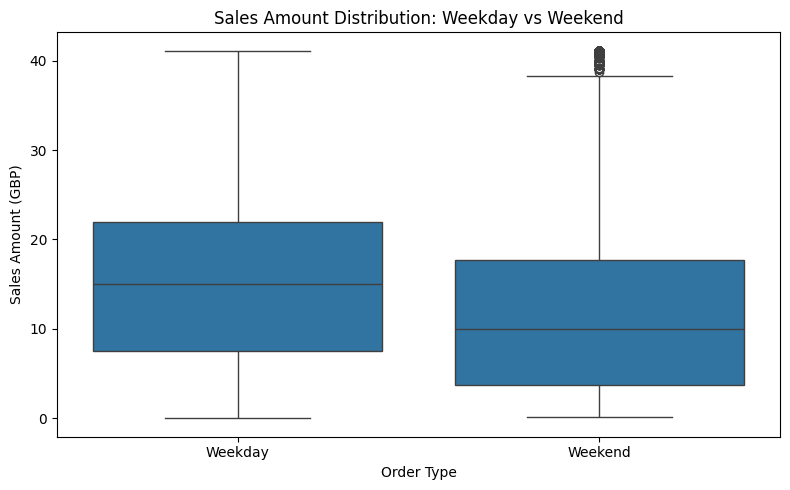

In [36]:
box_df = clean_df.copy()
box_df["weekend_label"] = box_df["is_weekend"].map({0: "Weekday", 1: "Weekend"})

plt.figure(figsize=(8, 5))
sns.boxplot(data=box_df, x="weekend_label", y="sales_amount_gbp")
plt.title("Sales Amount Distribution: Weekday vs Weekend")
plt.xlabel("Order Type")
plt.ylabel("Sales Amount (GBP)")
plt.tight_layout()
plt.show()

this box plot compares the sales distribution for weekday and weekend orders. It shows both the typical order value and the spread of values in each group.

Heatmap
Correlation heatmap for selected numeric columns.

In [ ]:
corr_cols = [
    "unit_price_gbp",
    "quantity_sold",
    "sales_amount_gbp",
    "population_total",
    "gdp_current_usd",
    "gdp_growth_pct",
    "inflation_consumer_pct"
]

corr_matrix = clean_df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

This heatmap summarizes the strength and direction of relationships between numeric variables. It is especially useful for spotting strongly related predictors and redundant features.

Export Cleaned Dataset

After applying the five preprocessing checks/functions, I exported the cleaned dataset as `diy_dataset.csv`.

In this dataset, most values were already clean, so the exported file is the cleaned submission version of the original dataset after validation and preprocessing.

In [38]:
# Export the cleaned dataset required for submission
# Even if the original Kaggle dataset was already largely clean,
# this exported file is the validated/processed version used in this notebook.
clean_df.to_csv("diy_dataset.csv", index=False)

print("Cleaned dataset exported successfully.")
print("Filename: diy_dataset.csv")
print("Rows, Columns:", clean_df.shape)

Cleaned dataset exported successfully.
Filename: diy_dataset.csv
Rows, Columns: (99745, 19)


The dataset was exported as `diy_dataset.csv`, which is the cleaned version used in this notebook. Although the original Kaggle file was already mostly clean, I still performed the required checks and saved the validated output file.